# Supplementary Plots

Given that all experiment notebooks (1-6) have run successfully, this notebook generates all the plots shown in the supplementary material of the manuscript.

In [1]:
import pickle
import os

from src.functions import *
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines

from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LogNorm

import seaborn as sns

import warnings
from pandas.errors import ParserWarning
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
# Create the directory if it doesn't exist
plots_dir = "supplementary_plots"
os.makedirs(plots_dir, exist_ok=True)

## Function Fitting Benchmarks

In [ ]:
cmap = sns.color_palette("crest", as_cmap=True)

# Generate data grid
N = 256
lin = np.linspace(-1.0, 1.0, N)
X, Y = np.meshgrid(lin, lin)
grid = np.stack([X.ravel(), Y.ravel()], axis=-1)  # shape (N^2, 2)

# Evaluate and reshape functions
functions = [
    f1(grid).reshape(N, N),
    f2(grid).reshape(N, N),
    f3(grid).reshape(N, N),
    f4(grid).reshape(N, N),
    f5(grid).reshape(N, N)
]
titles = [r'$f_1(x,y)$', r'$f_2(x,y)$', r'$f_3(x,y)$', r'$f_4(x,y)$', r'$f_5(x,y)$']

TITLE_FS = 14
LABEL_FS = 12
TICK_FS  = 10

In [ ]:
# Set up the figure using a 2x7 GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 7, height_ratios=[1, 1])

# Top row: f1 (0:2), f2 (2:4), f3 (4:6)
positions_top = [(0, 2), (2, 4), (4, 6)]
for i in range(3):
    ax = fig.add_subplot(gs[0, positions_top[i][0]:positions_top[i][1]])
    im = ax.pcolormesh(X, Y, functions[i], shading='auto', cmap=cmap)
    ax.set_title(titles[i], fontsize=TITLE_FS)
    ax.set_xlabel('x', fontsize=LABEL_FS)
    ax.set_ylabel('y', fontsize=LABEL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=TICK_FS)

# Bottom row: f4 (1:3), f5 (4:6) — centered below f2
ax4 = fig.add_subplot(gs[1, 1:3])
im4 = ax4.pcolormesh(X, Y, functions[3], shading='auto', cmap=cmap)
ax4.set_title(titles[3], fontsize=TITLE_FS)
ax4.set_xlabel('x', fontsize=LABEL_FS)
ax4.set_ylabel('y', fontsize=LABEL_FS)
ax4.tick_params(axis='both', labelsize=TICK_FS)
cbar4 = fig.colorbar(im4, ax=ax4)
cbar4.ax.tick_params(labelsize=TICK_FS)

ax5 = fig.add_subplot(gs[1, 3:5])
im5 = ax5.pcolormesh(X, Y, functions[4], shading='auto', cmap=cmap)
ax5.set_title(titles[4], fontsize=TITLE_FS)
ax5.set_xlabel('x', fontsize=LABEL_FS)
ax5.set_ylabel('y', fontsize=LABEL_FS)
ax5.tick_params(axis='both', labelsize=TICK_FS)
cbar5 = fig.colorbar(im5, ax=ax5)
cbar5.ax.tick_params(labelsize=TICK_FS)

plt.tight_layout()
fig.savefig(os.path.join(plots_dir, "functions.png"), dpi=300, bbox_inches='tight')

plt.show()

## PDE Benchmarks

In [ ]:
cmap = sns.color_palette("crest", as_cmap=True)

# Load Allen–Cahn (t, x, usol)
ac = np.load(os.path.join("data", "allen-cahn.npz"))
t_ac, x_ac, U_ac = ac["t"], ac["x"], ac["usol"].T
T_ac, X_ac = np.meshgrid(t_ac, x_ac, indexing="xy")

# Load Burgers (t, x, usol)
bg = np.load(os.path.join("data", "burgers.npz"))
t_bg, x_bg, U_bg = bg["t"], bg["x"], bg["usol"].T
T_bg, X_bg = np.meshgrid(t_bg, x_bg, indexing="xy")

# Load Helmholtz (x, y, usol)
hz = np.load(os.path.join("data", "helmholtz.npz"))
x_hz, y_hz, U_hz = hz["x"], hz["y"], hz["usol"].T
X_hz, Y_hz = np.meshgrid(x_hz, y_hz, indexing="xy")

TITLE_FS = 18
LABEL_FS = 16
TICK_FS  = 14

In [ ]:
y_hz.shape

In [ ]:
fig_pde, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
ims = []

# Allen–Cahn
im = axes[0].pcolormesh(T_ac, X_ac, U_ac, shading="auto", cmap=cmap)
axes[0].set_title("Allen–Cahn", fontsize=TITLE_FS)
axes[0].set_xlabel("t", fontsize=LABEL_FS)
axes[0].set_ylabel("x", fontsize=LABEL_FS)
axes[0].tick_params(axis="both", labelsize=TICK_FS)
ims.append(im)


# Burgers
im = axes[1].pcolormesh(T_bg, X_bg, U_bg, shading="auto", cmap=cmap)
axes[1].set_title("Burgers", fontsize=TITLE_FS)
axes[1].set_xlabel("t", fontsize=LABEL_FS)
axes[1].set_ylabel("x", fontsize=LABEL_FS)
axes[1].tick_params(axis="both", labelsize=TICK_FS)
ims.append(im)

# Helmholtz
im = axes[2].pcolormesh(X_hz, Y_hz, U_hz, shading="auto", cmap=cmap)
axes[2].set_title("Helmholtz", fontsize=TITLE_FS)
axes[2].set_xlabel("x", fontsize=LABEL_FS)
axes[2].set_ylabel("y", fontsize=LABEL_FS)
axes[2].tick_params(axis="both", labelsize=TICK_FS)
ims.append(im)

labels = [r"$u(x,t)$", r"$u(x,t)$", r"$u(x,y)$"]

for im, ax, lab in zip(ims, axes, labels):
    cbar = fig_pde.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_title(lab, pad=6, fontsize=LABEL_FS)
    cbar.ax.tick_params(labelsize=TICK_FS)

fig_pde.savefig(os.path.join(plots_dir, "pdes.png"), dpi=300, bbox_inches="tight")

plt.show()

## Loss Curves with LR Scheduling

In [ ]:
results_dir = 'ff_results/'

with open(os.path.join(results_dir, "losses_lr.pkl"), "rb") as f:
    results = pickle.load(f)

In [ ]:
# Plotting
num_epochs = 2000
cmap = sns.color_palette("crest", as_cmap=True)
spectral_points = np.linspace(0, 1, 20)
color_indices = [0, 6, 12, -1]

TITLE_FS = 22
LABEL_FS = 20
TICK_FS  = 18

init_types = ['baseline', 'lecun', 'glorot', 'power']
architectures = ['small', 'big']
func_names = list(results.keys())
func_plot_names = [r'$f_1(x,y)$', r'$f_2(x,y)$', r'$f_3(x,y)$', r'$f_4(x,y)$', r'$f_5(x,y)$']

colors = [cmap(spectral_points[i]) for i in color_indices]
custom_colors = dict(zip(init_types, colors))

fig, axes = plt.subplots(2, 5, figsize=(25, 10))

for col, func_name in enumerate(func_names):
    for row, arch in enumerate(architectures):
        ax = axes[row, col]
        
        for init in init_types:
            # Collect all runs for this configuration
            runs = []
            for run in results[func_name][arch]:
                arr = np.array(results[func_name][arch][run][init])
                runs.append(arr)
            runs = np.stack(runs)

            # Compute mean and standard error
            mean = runs.mean(axis=0)
            stderr = runs.std(axis=0) / np.sqrt(runs.shape[0])

            # Plot mean with stderr shaded area
            ax.plot(mean, label=init, color=custom_colors[init])
            ax.fill_between(np.arange(num_epochs), mean - stderr, mean + stderr, alpha=0.3, color=custom_colors[init])
            
            ax.tick_params(axis='both', labelsize=TICK_FS)

        # Labeling
        if row == 0:
            ax.set_title(func_plot_names[col], fontsize=TITLE_FS)
        if col == 0:
            ax.set_ylabel("Training Loss", fontsize=LABEL_FS, labelpad=10)
        if row == 1:
            ax.set_xlabel("Training Iteration", fontsize=LABEL_FS, labelpad=10)
        if col == len(func_names) - 1:
            ax.text(1.10, 0.5, r'$G = 5$, depth = 2, width = 8' if row == 0 else r'$G = 20$, depth = 3, width = 32', transform=ax.transAxes,
                    fontsize=TICK_FS, rotation=270, va='center', ha='left')

        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.55)

# Construct legend manually
handles = [
    mlines.Line2D([], [], color=custom_colors['baseline'], label='Baseline', linewidth=3),
    mlines.Line2D([], [], color=custom_colors['lecun'], label='LeCun', linewidth=3),
    mlines.Line2D([], [], color=custom_colors['glorot'], label='Glorot', linewidth=3),
    mlines.Line2D([], [], color=custom_colors['power'], label='Power-Law', linewidth=3),
]

# Add global legend
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=LABEL_FS, frameon=False, bbox_to_anchor=(0.5, -0.05))

plt.subplots_adjust(hspace=0.35, wspace=0.3, bottom=0.1)

fig.savefig(os.path.join(plots_dir, "ff_losses_lr.pdf"), bbox_inches='tight')

plt.show()

In [ ]:
results_dir = 'pde_results/'

with open(os.path.join(results_dir, "losses_lr.pkl"), "rb") as f:
    results = pickle.load(f)

In [ ]:
# Plotting
num_epochs = 5000
cmap = sns.color_palette("crest", as_cmap=True)
spectral_points = np.linspace(0, 1, 20)
color_indices = [0, 6, 12, -1]

TITLE_FS = 18
LABEL_FS = 16
TICK_FS  = 14

init_types = ['baseline', 'lecun', 'glorot', 'power']
architectures = ['small', 'big']
func_names = list(results.keys())
func_plot_names = ['Allen-Cahn', 'Burgers', 'Helmholtz']

colors = [cmap(spectral_points[i]) for i in color_indices]
custom_colors = dict(zip(init_types, colors))

fig, axes = plt.subplots(2, 3, figsize=(20, 7))

for col, func_name in enumerate(func_names):
    for row, arch in enumerate(architectures):
        ax = axes[row, col]
        
        for init in init_types:
            # Collect all runs for this configuration
            runs = []
            for run in results[func_name][arch]:
                arr = np.array(results[func_name][arch][run][init])
                runs.append(arr)
            runs = np.stack(runs)

            # Compute mean and standard error
            mean = runs.mean(axis=0)
            stderr = runs.std(axis=0) / np.sqrt(runs.shape[0])

            # Plot mean with stderr shaded area
            ax.plot(mean, label=init, color=custom_colors[init])
            ax.fill_between(np.arange(num_epochs), mean - stderr, mean + stderr, alpha=0.3, color=custom_colors[init])
            
            ax.tick_params(axis='both', labelsize=TICK_FS)

        # Labeling
        if row == 0:
            ax.set_title(func_plot_names[col], fontsize=TITLE_FS)
        if col == 0:
            ax.set_ylabel("Training Loss", fontsize=LABEL_FS, labelpad=10)
        if row == 1:
            ax.set_xlabel("Training Iteration", fontsize=LABEL_FS, labelpad=10)
        if col == len(func_names) - 1:
            ax.text(1.10, 0.5, '            G = 5\ndepth = 2, width = 8' if row == 0 else '            G = 20\ndepth = 3, width = 32', transform=ax.transAxes,
                    fontsize=LABEL_FS, rotation=270, va='center', ha='left')
        
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.55)

# Construct legend manually
handles = [
    mlines.Line2D([], [], color=custom_colors['baseline'], label='Baseline', linewidth=3),
    mlines.Line2D([], [], color=custom_colors['lecun'], label='LeCun', linewidth=3),
    mlines.Line2D([], [], color=custom_colors['glorot'], label='Glorot', linewidth=3),
    mlines.Line2D([], [], color=custom_colors['power'], label='Power-Law', linewidth=3),
]

# Add global legend
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=LABEL_FS, frameon=False, bbox_to_anchor=(0.5, -0.08))

plt.subplots_adjust(hspace=0.25, wspace=0.2, bottom=0.1)

fig.savefig(os.path.join(plots_dir, "pde_losses_lr.pdf"), bbox_inches='tight')

plt.show()

## Full Grid-Search Plots: Function Fitting

In [ ]:
results_dir = 'ff_results/'
gs = pd.read_csv(os.path.join(results_dir, 'grid_search.csv'), sep=',')

# Isolate the run with the median performance for confidence
gs_sorted = gs.sort_values("loss")

# Grouping columns, including pow_res and pow_basis
group_cols = ['method', 'function', 'G', 'width', 'depth', 'pow_res', 'pow_basis']

# Define a function to get the row with the median loss
def get_median_row(group):
    median_loss = group['loss'].median()
    # Use idxmin on absolute difference to median to break ties predictably
    idx = (group['loss'] - median_loss).abs().idxmin()
    return group.loc[[idx]]

# Apply the function group-wise and reset the index
mgs = gs_sorted.groupby(group_cols, dropna=False, group_keys=False).apply(get_median_row).reset_index(drop=True)

# Filter to only 'power' method
power_df = mgs[mgs['method'] == 'power'].copy()

# Group by function and architecture (G, width, depth), and find row with minimal loss
best_power_configs = (
    power_df
    .groupby(['function', 'G', 'width', 'depth'], dropna=False, group_keys=False)
    .apply(lambda g: g.loc[g['loss'].idxmin()])
    .reset_index(drop=True)
)

# Drop pow_res and pow_basis from the whole filtered set
mgs_nopow = mgs.drop(columns=['pow_res', 'pow_basis', 'run'])

# Drop pow_res and pow_basis from best_power_configs too
best_power_configs_nopow = best_power_configs.drop(columns=['pow_res', 'pow_basis', 'run'])

# Filter out original 'power' rows from mgs_nopow
non_power_rows = mgs_nopow[mgs_nopow['method'] != 'power']

# Combine best 'power' rows with all other methods
fgs = pd.concat([non_power_rows, best_power_configs_nopow], ignore_index=True)

### Different Initialization Results

In [ ]:
def plot_all_inits_func(G_val):

    TITLE_FS = 22
    LABEL_FS = 20
    TICK_FS  = 18
    CBAR_LABEL_FS = 20
    CBAR_TICK_FS  = 18
    ANNOT_FS = 8

    # Set plot config
    colormap = sns.color_palette("crest_r", as_cmap=True)
    figsize = (25, 20)
    
    method_dict = {"baseline": "Baseline", "lecun_numer": "LeCun-Numerical", "lecun_norm": "LeCun-Normalized", "glorot": "Glorot", "power": "Power Law"}
    func_dict = {"f1": r"$f_1(x,y)$", "f2": r"$f_2(x,y)$", "f3": r"$f_3(x,y)$", "f4": r"$f_4(x,y)$", "f5": r"$f_5(x,y)$"}
    
    # Plotting
    fig, axes = plt.subplots(nrows=5, ncols=5, figsize=figsize, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, wspace=0.07, hspace=0.07)

    subset = fgs[fgs['G'] == G_val]

    for i, func in enumerate(fgs['function'].unique()):
        func_subset = subset[subset['function'] == func]

        for j, method in enumerate(fgs['method'].unique()):
            ax = axes[i, j]
            heat_data = func_subset[func_subset['method'] == method].pivot(
                index='depth', columns='width', values='loss'
            )
            heat_data = heat_data.reindex(index=[4, 3, 2, 1])
            sns.heatmap(heat_data, ax=ax, cmap=colormap, cbar=True, annot=False, fmt=".1e", annot_kws={"fontsize": ANNOT_FS})

            colorbar = ax.collections[0].colorbar
            colorbar.formatter = ScalarFormatter(useMathText=True)
            colorbar.formatter.set_powerlimits((-1, 1))
            colorbar.update_ticks()

            colorbar.ax.tick_params(labelsize=CBAR_TICK_FS)
            colorbar.ax.yaxis.offsetText.set_fontsize(CBAR_TICK_FS)
            colorbar.ax.yaxis.offsetText.set_horizontalalignment('center')

            ax.tick_params(axis='both', labelsize=TICK_FS)
            
            if i == 0:
                ax.set_title(method_dict[method], fontsize=TITLE_FS, pad=10)
            if j == 4:
                cbar = ax.collections[0].colorbar
                cbar.set_label(func_dict[func], rotation=270, labelpad=35, fontsize=CBAR_LABEL_FS)
            else:
                ax.set_ylabel('')
            ax.set_xlabel('' if i < 4 else 'Width', fontsize=LABEL_FS)
            ax.set_ylabel('Depth' if j == 0 else '', fontsize=LABEL_FS)

            # Hide y-axis ticks for non-leftmost plots
            if j != 0:
                ax.set_yticklabels([])
                ax.set_ylabel('')
            
            # Hide x-axis ticks for non-bottom plots
            if i != 4:
                ax.set_xticklabels([])
                ax.set_xlabel('')
    
    #fig.savefig(os.path.join(plots_dir, f"ff_G{G_val}.pdf"), bbox_inches='tight')
    
    plt.show()

In [ ]:
for G_val in [5, 10, 20, 40]:
    plot_all_inits_func(G_val)

In [ ]:
plot_all_inits_func(5)

### Power-law Grid-Search

In [ ]:
def plot_power_func(G_val, func):

    power_df = mgs.loc[mgs['method']=='power'].loc[mgs['function']==func]
    power_df = power_df[['G', 'width', 'depth', 'pow_res', 'pow_basis', 'loss']]
    power_df.reset_index(inplace=True, drop=True)

    TITLE_FS = 22
    LABEL_FS = 20
    TICK_FS  = 18
    CBAR_LABEL_FS = 20
    CBAR_TICK_FS  = 18
    
    # Set plot config
    colormap = sns.color_palette("crest_r", as_cmap=True)
    figsize = (20, 25)
    alpha_values = sorted(power_df['pow_res'].unique())
    beta_values = sorted(power_df['pow_basis'].unique())

    
    fig, axes = plt.subplots(nrows=6, ncols=4, figsize=figsize, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, wspace=0.07, hspace=0.07)
    subset = power_df[(power_df['G'] == G_val)]

    for i, width in enumerate(sorted(subset['width'].unique())):
        width_subset = subset[subset['width'] == width]

        for j, depth in enumerate(sorted(subset['depth'].unique())):
            ax = axes[i, j]
            heat_data = width_subset[width_subset['depth'] == depth].pivot(
                index='pow_basis', columns='pow_res', values='loss'
            )
            heat_data = heat_data.reindex(index=sorted(heat_data.index, reverse=True))

            # Compute local vmin/vmax for log normalization
            local_vmin = np.nanmin(heat_data.values)
            local_vmax = np.nanmax(heat_data.values)
            
            # Avoid errors with zero or negative values (required for LogNorm)
            if local_vmin <= 0:
                local_vmin = 1e-12
            
            norm = LogNorm(vmin=local_vmin, vmax=local_vmax)

            sns.heatmap(
                heat_data,
                ax=ax,
                cmap=colormap,
                cbar=True,
                norm=norm
            )

            xticks = ax.get_xticks()
            xticklabels = [float(lbl.get_text()) for lbl in ax.get_xticklabels()]
            filtered_xticklabels = [str(l) if l in {0.0, 0.5, 1.0, 1.5, 2.0} else '' for l in xticklabels]
            ax.set_xticklabels(filtered_xticklabels)

            yticks = ax.get_yticks()
            yticklabels = [float(lbl.get_text()) for lbl in ax.get_yticklabels()]
            filtered_yticklabels = [str(l) if l in {0.0, 0.5, 1.0, 1.5, 2.0} else '' for l in yticklabels]
            ax.set_yticklabels(filtered_yticklabels)

            ax.tick_params(axis='both', labelsize=TICK_FS)

            colorbar = ax.collections[0].colorbar
            colorbar.ax.tick_params(labelsize=CBAR_TICK_FS)

            if i == 0:
                ax.set_title(f"Depth = {depth}", fontsize=TITLE_FS, pad=10)
            if j == 3:
                cbar = ax.collections[0].colorbar
                cbar.set_label(f"Width = {width}", rotation=270, labelpad=35, fontsize=CBAR_LABEL_FS)
            else:
                ax.set_ylabel("")
            ax.set_xlabel('' if i < 4 else r"$\alpha$", fontsize=LABEL_FS)
            ax.set_ylabel(r"$\beta$" if j == 0 else "", fontsize=LABEL_FS)

            # Hide y-axis ticks for non-leftmost plots
            if j != 0:
                ax.set_yticklabels([])
                ax.set_ylabel('')
            
            # Hide x-axis ticks for non-bottom plots
            if i != 5:
                ax.set_xticklabels([])
                ax.set_xlabel('')

    #fig.savefig(os.path.join(plots_dir, f"G{G_val}_{func}.png"), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(plots_dir, f"G{G_val}_{func}.pdf"), bbox_inches='tight')
    
    plt.show()

In [ ]:
for G_val in [5, 10, 20, 40]:
    for func in ['f1', 'f2', 'f3', 'f4', 'f5']:
        plot_power_func(G_val, func)

In [ ]:
plot_power_func(5, 'f3')

## Full Grid-Search Plots: PDE Solving

In [ ]:
results_dir = 'pde_results/'
gs = pd.read_csv(os.path.join(results_dir, 'grid_search.csv'), sep=',')

# Isolate the run with the median performance for confidence
gs_sorted = gs.sort_values("loss")

# Grouping columns, including pow_res and pow_basis
group_cols = ['method', 'pde', 'G', 'width', 'depth', 'pow_res', 'pow_basis']

# Define a function to get the row with the median loss
def get_median_row(group):
    s = group['loss'].dropna()
    if s.empty:
        return group.iloc[0:0]  # drop this experiment (no valid loss)
    med = s.median()
    idx = (s - med).abs().idxmin()
    return group.loc[[idx]]

# Apply the function group-wise and reset the index
mgs = gs_sorted.groupby(group_cols, dropna=False, group_keys=False).apply(get_median_row).reset_index(drop=True)

# Filter to only 'power' method
power_df = mgs[mgs['method'] == 'power'].copy()

# Group by function and architecture (G, width, depth), and find row with minimal loss
best_power_configs = (
    power_df
    .groupby(['pde', 'G', 'width', 'depth'], dropna=False, group_keys=False)
    .apply(lambda g: g.loc[g['loss'].idxmin()])
    .reset_index(drop=True)
)

# Drop pow_res and pow_basis from the whole filtered set
mgs_nopow = mgs.drop(columns=['pow_res', 'pow_basis', 'run'])

# Drop pow_res and pow_basis from best_power_configs too
best_power_configs_nopow = best_power_configs.drop(columns=['pow_res', 'pow_basis', 'run'])

# Filter out original 'power' rows from mgs_nopow
non_power_rows = mgs_nopow[mgs_nopow['method'] != 'power']

# Combine best 'power' rows with all other methods
fgs = pd.concat([non_power_rows, best_power_configs_nopow], ignore_index=True)

### Different Initialization Results

In [ ]:
def plot_all_inits_pde(G_val):

    TITLE_FS = 22
    LABEL_FS = 20
    TICK_FS  = 18
    CBAR_LABEL_FS = 20
    CBAR_TICK_FS  = 18
    ANNOT_FS = 8

    # Set plot config
    colormap = sns.color_palette("crest_r", as_cmap=True)
    figsize = (25, 12)
    
    method_dict = {"baseline": "Baseline", "lecun_numer": "LeCun-Numerical", "lecun_norm": "LeCun-Normalized", "glorot": "Glorot", "power": "Power Law"}
    pde_dict = {"ac": "Allen–Cahn", "burgers": "Burgers", "helmholtz": "Helmholtz"}
    
    # Plotting
    fig, axes = plt.subplots(nrows=3, ncols=5, figsize=figsize, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, wspace=0.07, hspace=0.07)

    subset = fgs[fgs['G'] == G_val]

    for i, pde in enumerate(fgs['pde'].unique()):
        pde_subset = subset[subset['pde'] == pde]

        for j, method in enumerate(fgs['method'].unique()):
            ax = axes[i, j]
            heat_data = pde_subset[pde_subset['method'] == method].pivot(
                index='depth', columns='width', values='loss'
            )
            heat_data = heat_data.reindex(index=[4, 3, 2, 1])
            sns.heatmap(heat_data, ax=ax, cmap=colormap, cbar=True, annot=False, fmt=".1e", annot_kws={"fontsize": ANNOT_FS})

            colorbar = ax.collections[0].colorbar
            
            colorbar.formatter = ScalarFormatter(useMathText=True)
            colorbar.formatter.set_powerlimits((-1, 1))
            colorbar.update_ticks()

            colorbar.ax.tick_params(labelsize=CBAR_TICK_FS)
            colorbar.ax.yaxis.offsetText.set_fontsize(CBAR_TICK_FS)
            colorbar.ax.yaxis.offsetText.set_horizontalalignment('center')

            ax.tick_params(axis='both', labelsize=TICK_FS)
            
            if i == 0:
                ax.set_title(method_dict[method], fontsize=TITLE_FS, pad=10)
            if j == 4:
                cbar = ax.collections[0].colorbar
                cbar.set_label(pde_dict[pde], rotation=270, labelpad=35, fontsize=CBAR_LABEL_FS)
            else:
                ax.set_ylabel('')
            ax.set_xlabel('' if i < 2 else 'Width', fontsize=LABEL_FS)
            ax.set_ylabel('Depth' if j == 0 else '', fontsize=LABEL_FS)

            # Hide y-axis ticks for non-leftmost plots
            if j != 0:
                ax.set_yticklabels([])
                ax.set_ylabel('')
            
            # Hide x-axis ticks for non-bottom plots
            if i != 2:
                ax.set_xticklabels([])
                ax.set_xlabel('')
    
    #fig.savefig(os.path.join(plots_dir, f"pde_G{G_val}.pdf"), bbox_inches='tight')
    
    plt.show()

In [ ]:
for G_val in [5, 10, 20]:
    plot_all_inits_pde(G_val)

In [ ]:
plot_all_inits_pde(5)

### Power-law Grid-Search

In [ ]:
def plot_power_pde(G_val, pde):

    power_df = mgs.loc[mgs['method']=='power'].loc[mgs['pde']==pde]
    power_df = power_df[['G', 'width', 'depth', 'pow_res', 'pow_basis', 'loss']]
    power_df.reset_index(inplace=True, drop=True)

    TITLE_FS = 22
    LABEL_FS = 20
    TICK_FS  = 18
    CBAR_LABEL_FS = 20
    CBAR_TICK_FS  = 18
    
    # Set plot config
    colormap = sns.color_palette("crest_r", as_cmap=True)
    figsize = (20, 25)
    alpha_values = sorted(power_df['pow_res'].unique())
    beta_values = sorted(power_df['pow_basis'].unique())

    
    fig, axes = plt.subplots(nrows=6, ncols=4, figsize=figsize, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, wspace=0.07, hspace=0.07)
    subset = power_df[(power_df['G'] == G_val)]

    for i, width in enumerate(sorted(subset['width'].unique())):
        width_subset = subset[subset['width'] == width]

        for j, depth in enumerate(sorted(subset['depth'].unique())):
            ax = axes[i, j]
            heat_data = width_subset[width_subset['depth'] == depth].pivot(
                index='pow_basis', columns='pow_res', values='loss'
            )
            heat_data = heat_data.reindex(index=sorted(heat_data.index, reverse=True))

            # Compute local vmin/vmax for log normalization
            local_vmin = np.nanmin(heat_data.values)
            local_vmax = np.nanmax(heat_data.values)
            
            # Avoid errors with zero or negative values (required for LogNorm)
            if local_vmin <= 0:
                local_vmin = 1e-12
            
            norm = LogNorm(vmin=local_vmin, vmax=local_vmax)

            sns.heatmap(
                heat_data,
                ax=ax,
                cmap=colormap,
                cbar=True,
                norm=norm
            )

            xticks = ax.get_xticks()
            xticklabels = [float(lbl.get_text()) for lbl in ax.get_xticklabels()]
            filtered_xticklabels = [str(l) if l in {0.0, 0.5, 1.0, 1.5, 2.0} else '' for l in xticklabels]
            ax.set_xticklabels(filtered_xticklabels)

            yticks = ax.get_yticks()
            yticklabels = [float(lbl.get_text()) for lbl in ax.get_yticklabels()]
            filtered_yticklabels = [str(l) if l in {0.0, 0.5, 1.0, 1.5, 2.0} else '' for l in yticklabels]
            ax.set_yticklabels(filtered_yticklabels)

            ax.tick_params(axis='both', labelsize=TICK_FS)

            colorbar = ax.collections[0].colorbar
            colorbar.ax.tick_params(labelsize=CBAR_TICK_FS)

            if i == 0:
                ax.set_title(f"Depth = {depth}", fontsize=TITLE_FS, pad=10)
            if j == 3:
                cbar = ax.collections[0].colorbar
                cbar.set_label(f"Width = {width}", rotation=270, labelpad=35, fontsize=CBAR_LABEL_FS)
            else:
                ax.set_ylabel("")
            ax.set_xlabel('' if i < 4 else r"$\alpha$", fontsize=LABEL_FS)
            ax.set_ylabel(r"$\beta$" if j == 0 else "", fontsize=LABEL_FS)

            # Hide y-axis ticks for non-leftmost plots
            if j != 0:
                ax.set_yticklabels([])
                ax.set_ylabel('')
            
            # Hide x-axis ticks for non-bottom plots
            if i != 5:
                ax.set_xticklabels([])
                ax.set_xlabel('')

    #fig.savefig(os.path.join(plots_dir, f"G{G_val}_{pde}.png"), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(plots_dir, f"G{G_val}_{pde}.pdf"), bbox_inches='tight')
    
    plt.show()

In [ ]:
for G_val in [5, 10, 20]:
    for pde in ['ac', 'burgers', 'helmholtz']:
        plot_power_pde(G_val, pde)

In [ ]:
plot_power_pde(5, 'ac')

## NTK Spectra Grid for Power-Law

In [7]:
with open("ntk_powgrid.pkl", "rb") as f:
    results = pickle.load(f)

pows = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]

In [25]:
def plot_ntk_power_grid(results, pows, plots_dir, func_key="function"):
    """
    Plot a |pows| x |pows| grid of NTK spectra.
    
    rows   = pow_res (a)
    cols   = pow_basis (b)
    cell(i,j) => results[func_key][pow_res][pow_basis]["spec_list"]
    """

    TITLE_FS = 14
    LABEL_FS = 16
    TICK_FS  = 10

    # Colors like before
    palette = sns.color_palette("crest", 20)
    c_init  = palette[-1]
    c_mid   = palette[10]
    c_final = palette[0]

    n = len(pows)
    fig, axes = plt.subplots(n, n, figsize=(2*n, 2*n), sharex=True, sharey=False)

    # In case pows is not sorted and you want a nice order:
    pows_sorted = list(pows)

    if func_key == "function":
        spec = "spec_list"
    else:
        spec = "specE_list"

    for i, pow_res in enumerate(pows_sorted):
        for j, pow_basis in enumerate(pows_sorted):
            ax = axes[i, j] if n > 1 else axes
            cell = results[func_key].get(pow_res, {}).get(pow_basis, None)

            if cell is None or spec not in cell:
                ax.set_visible(False)
                continue

            specs = [np.asarray(e) for e in cell[spec]]
            if len(specs) == 0:
                ax.set_visible(False)
                continue

            idx = np.arange(1, specs[0].size + 1)

            # Initialization
            ax.plot(idx, specs[0], color=c_init, lw=1.5, label="Initialization")

            # Intermediates
            if len(specs) > 2:
                for lam in specs[1:-1]:
                    ax.plot(
                        idx, lam, "--", color=c_mid, alpha=0.6,
                        label="Intermediate Iterations" if (i == 0 and j == 0) else None
                    )

            # Final
            if len(specs) > 1:
                ax.plot(idx, specs[-1], "--", color=c_final, lw=1.5,
                        label="Final Iteration")

            ax.set_xscale("log")
            ax.set_yscale("log")

            # Top row: column labels (basis exponent b)
            if i == 0:
                ax.set_title(fr"$\beta$ = {pow_basis}", fontsize=TITLE_FS)

            # First column: row labels (residual exponent a)
            if j == 0:
                ax.set_ylabel(fr"$\alpha$ = {pow_res}", fontsize=TITLE_FS)

            # Only bottom row: x-label
            if i == n - 1:
                ax.set_xlabel("Index", fontsize=LABEL_FS)

            ax.tick_params(axis="both", labelsize=TICK_FS)
            ax.grid(True, which="both", linestyle="--", linewidth=0.25, alpha=0.55)

    # Global axis labels (for the whole figure)
    fig.supxlabel("Eigenvalue index (log scale)", fontsize=LABEL_FS)
    fig.supylabel("Eigenvalues (log scale)", fontsize=LABEL_FS)

    # Global legend outside
    handles = [
        mlines.Line2D([], [], color=c_init,  label="Initialization", linewidth=2),
        mlines.Line2D([], [], color=c_mid,   label="Intermediate Iterations", linewidth=2, linestyle="--"),
        mlines.Line2D([], [], color=c_final, label="Final Iteration", linewidth=2, linestyle="--"),
    ]

    fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=LABEL_FS,
               frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.subplots_adjust(hspace=0.3, wspace=0.3, bottom=0.06, left=0.08, right=0.98, top=0.94)
    
    fig.savefig(os.path.join(plots_dir, f"ntk_grid_ff.pdf"), bbox_inches="tight")
    
    plt.show()

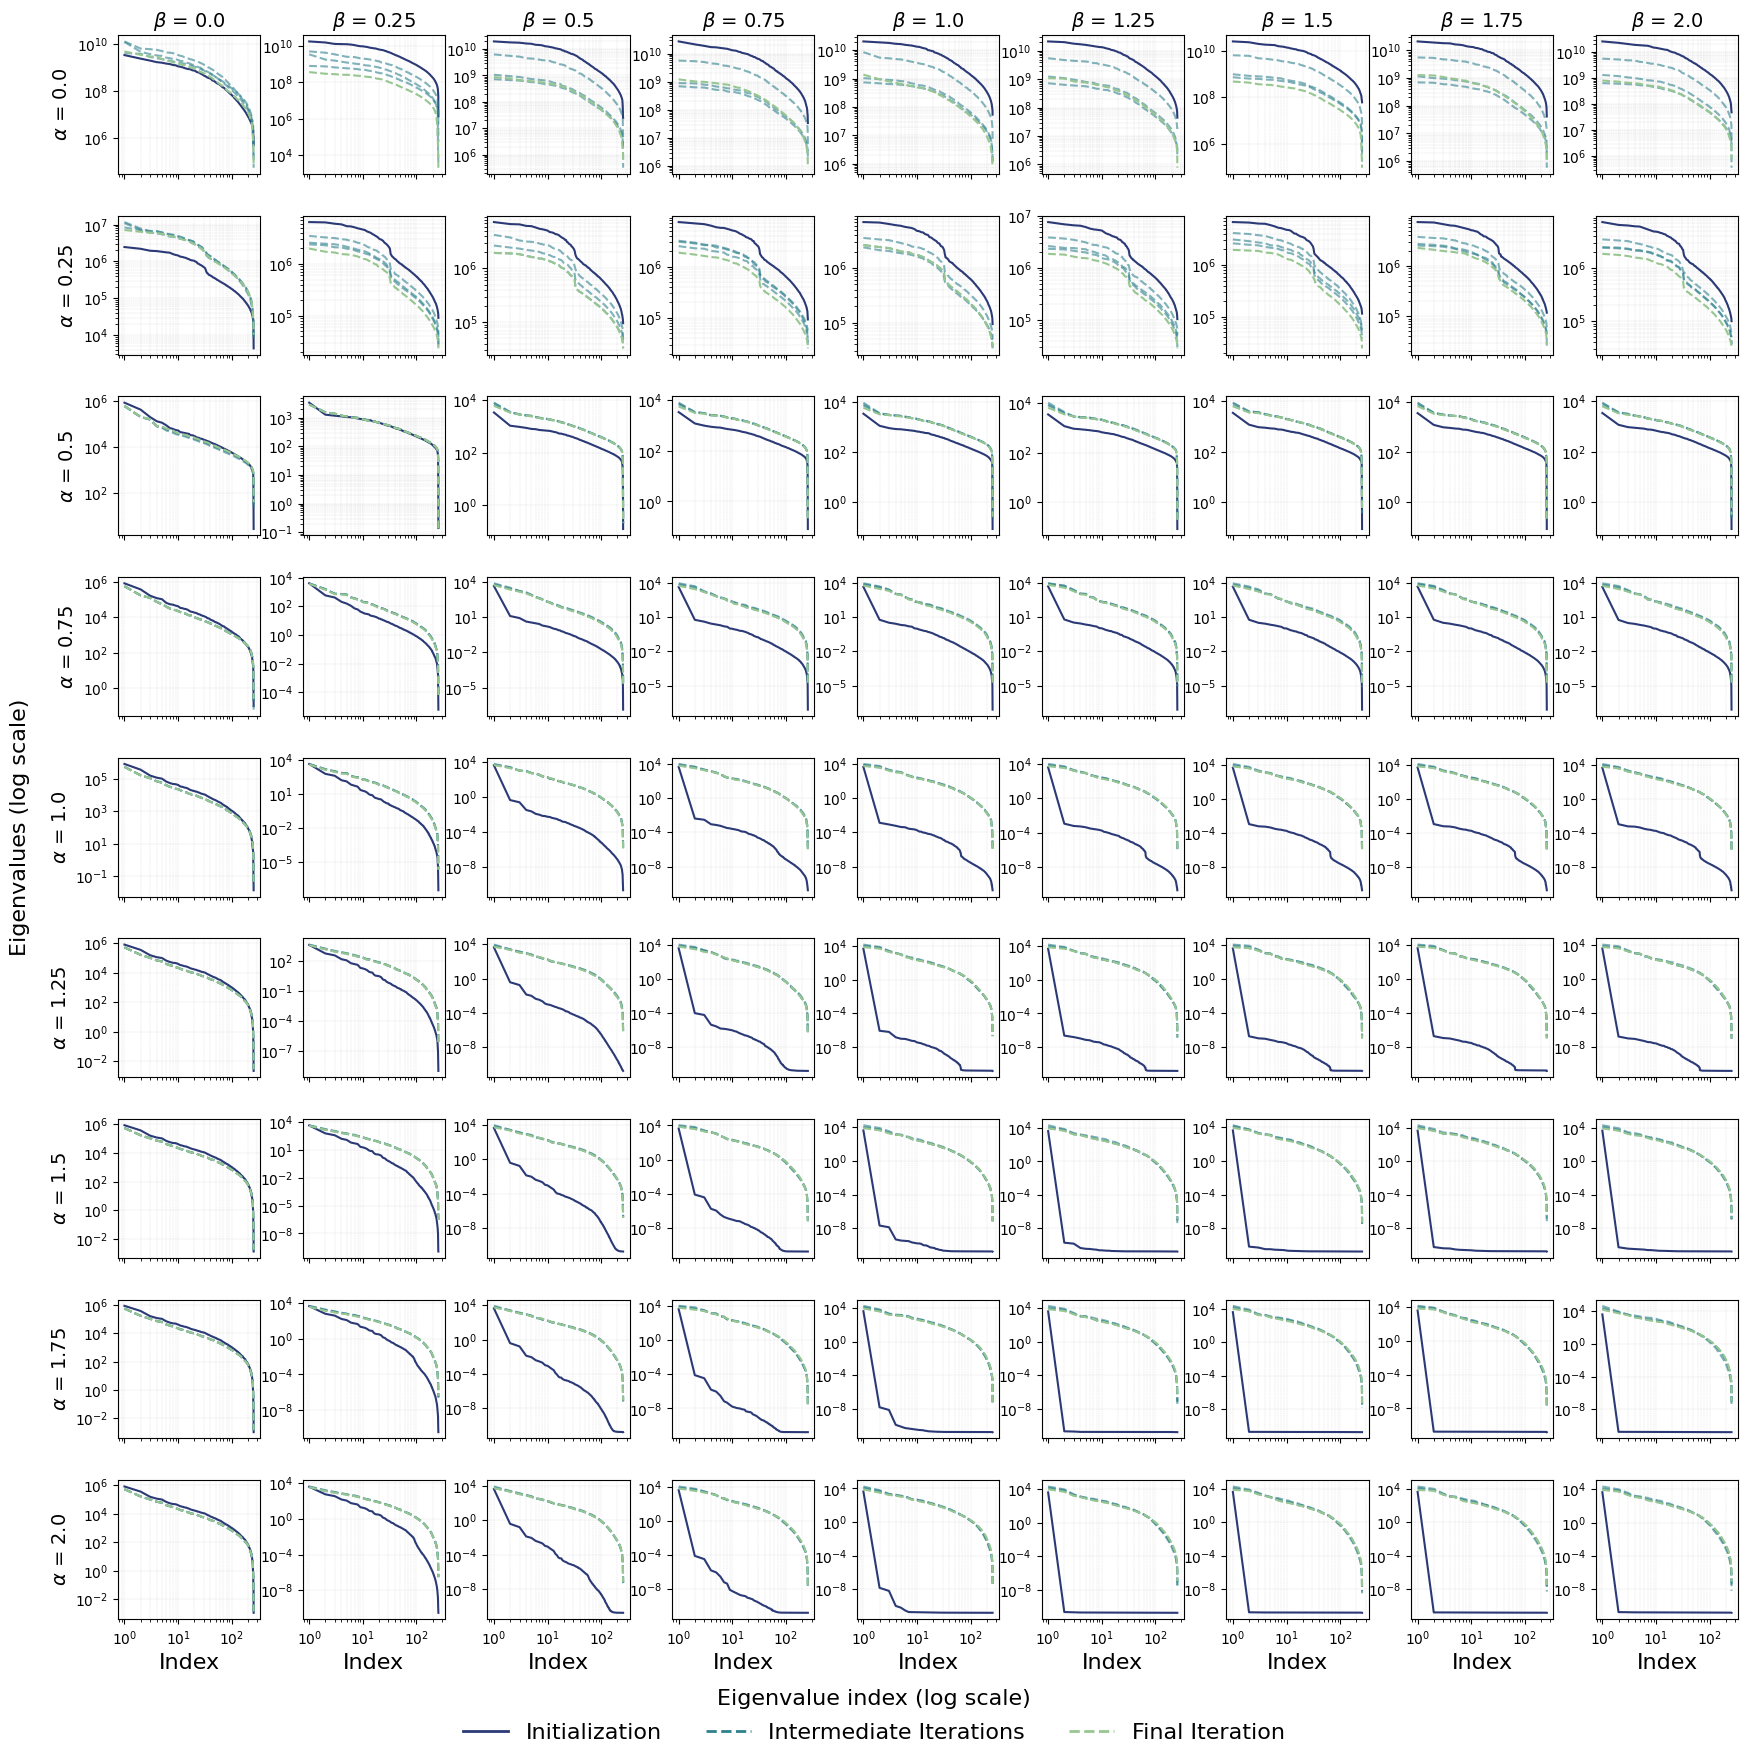

In [26]:
plot_ntk_power_grid(results, pows, plots_dir, func_key="function")